In [2]:
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.metrics import rand_score
import time

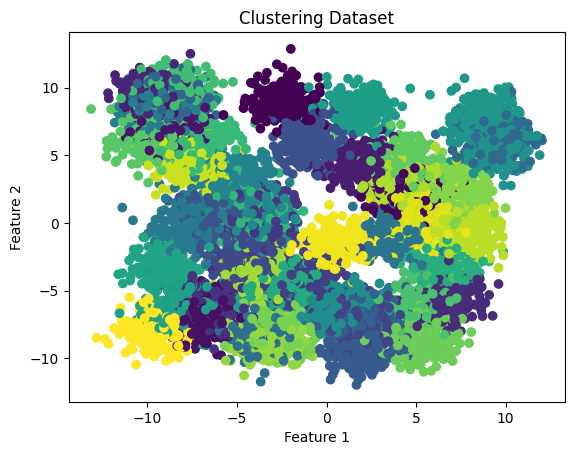

In [3]:
X, y = make_blobs(n_samples=10000, centers=50, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clustering Dataset')
plt.show()

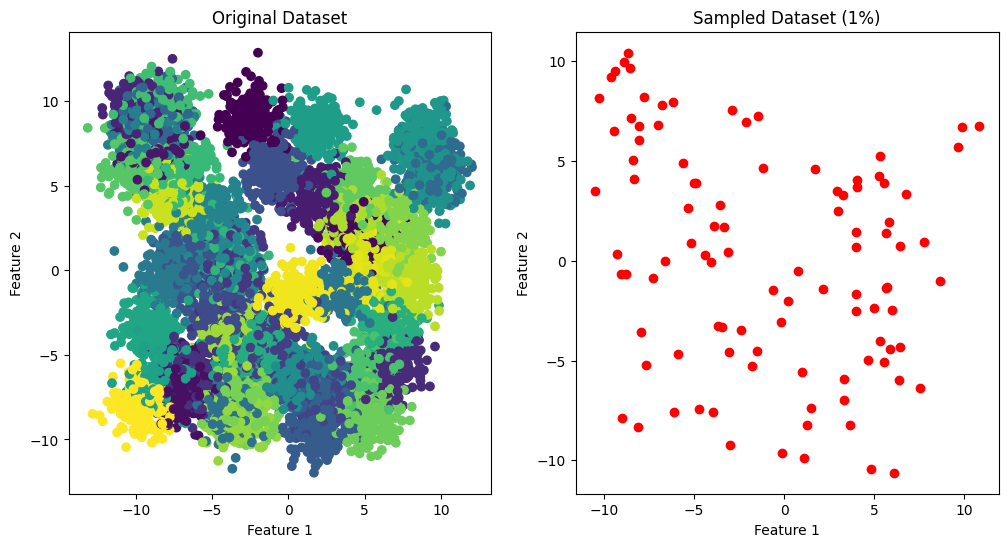

In [4]:
def uniform_sample(percentage, data):

    n_samples = int(percentage * len(data))
    indices = np.random.choice(len(data), size = n_samples, replace=False)
    return data[indices]

sampled_X = uniform_sample(0.01, X)

# Plotting the original dataset
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Dataset')

# Plotting the sampled dataset
plt.subplot(1, 2, 2)
plt.scatter(sampled_X[:, 0], sampled_X[:, 1], c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sampled Dataset (1%)')

plt.show()


/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


time for unsampled data : 1.1746723651885986
time for sampled data : 0.020068883895874023
Rand Index: 0.9351


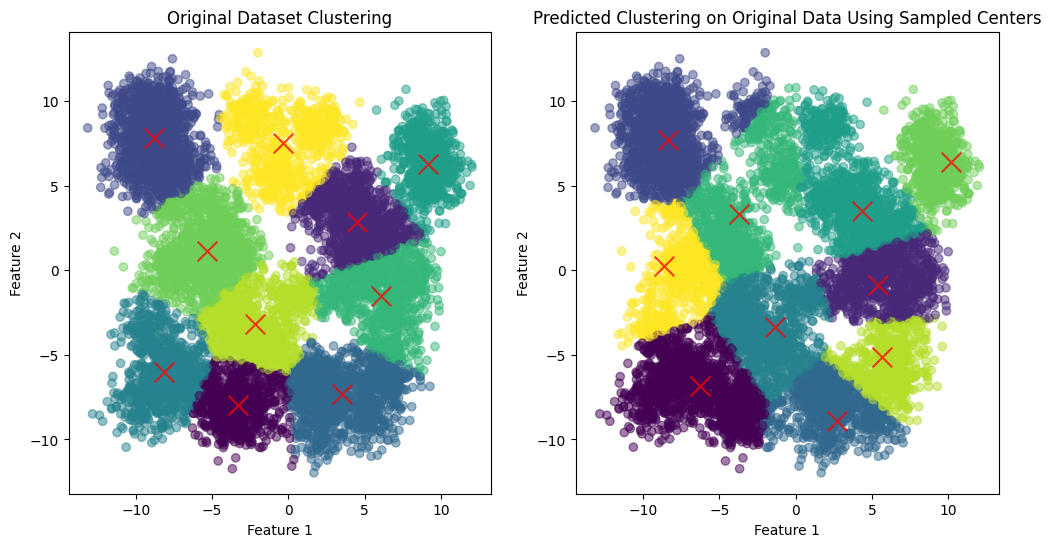

0.9015349334933493
0.9075584358435843


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
from scipy.spatial.distance import cdist  # Import cdist to compute distances

# Function to apply K-means clustering and time the process
def apply_kmeans_and_time(data, n_clusters):
    start_time = time.time()
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(data)
    elapsed_time = time.time() - start_time
    return kmeans.labels_, kmeans.cluster_centers_, elapsed_time

# Function to predict labels based on nearest centroids
def predict(data, centroids):
    dist = cdist(data, centroids)
    labels = np.argmin(dist, axis=1)
    return labels

# Function to compare clustering results and compute Rand Index
def compare_and_evaluate_clusters(original_data, original_labels, centers,sampled_labels_centers, predicted_labels):

    rand_index = rand_score(original_labels, predicted_labels)
    print(f"Rand Index: {rand_index:.4f}")
    
    plt.figure(figsize=(12, 6))
    
    # Plotting the original dataset with actual cluster centers
    plt.subplot(1, 2, 1)
    plt.scatter(original_data[:, 0], original_data[:, 1], c=original_labels, cmap='viridis', alpha=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Original Dataset Clustering')

    # Plotting the sampled dataset with predicted cluster centers
    plt.subplot(1, 2, 2)
    plt.scatter(original_data[:, 0], original_data[:, 1], c=predicted_labels, cmap='viridis', alpha=0.5)  # Use predicted_labels for coloring
    plt.scatter(sampled_labels_centers[:, 0], sampled_labels_centers[:, 1], c='red', s=200, alpha=0.75, marker='x')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Predicted Clustering on Original Data Using Sampled Centers')
    
    plt.show()


# Apply K-means to the original and sampled datasets with timing
original_labels, centers, original_time = apply_kmeans_and_time(X, 10)
sampled_labels, sampled_labels_centers, sampled_time = apply_kmeans_and_time(sampled_X, 10)

print("time for unsampled data :",original_time)
print("time for sampled data :",sampled_time)

# Predict labels for the original dataset using centroids from the sampled data
predicted_labels = predict(X, sampled_labels_centers)

# Compare and evaluate the results
compare_and_evaluate_clusters(X,  original_labels, centers,sampled_labels_centers, predicted_labels)

print(rand_score(y,predicted_labels))
print(rand_score(y,original_labels))

In [6]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

test_images_vector = test_images.reshape(test_images.shape[0], -1)
train_images_vector = train_images.reshape(train_images.shape[0], -1)

print(np.shape(test_images_vector))
print(np.shape(train_images_vector))

2024-04-22 14:08:31.341759: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-22 14:08:31.916778: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-22 14:08:31.916857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-22 14:08:31.989204: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-22 14:08:32.127615: I tensorflow/core/platform/cpu_feature_guar

(10000, 784)
(60000, 784)


In [7]:
sampled_data = uniform_sample(0.01,test_images_vector)

print(np.shape(sampled_data))

labels, centers, samay = apply_kmeans_and_time(test_images_vector,10)
labels1, centers1, samay1 = apply_kmeans_and_time(sampled_data,10)

print("time to cluster entire dataset : ",samay)
print("time to cluster the sampled dataset : ",samay1)

(100, 784)


/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


time to cluster entire dataset :  8.08137559890747
time to cluster the sampled dataset :  0.08478426933288574


/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Rand Index: 0.8971


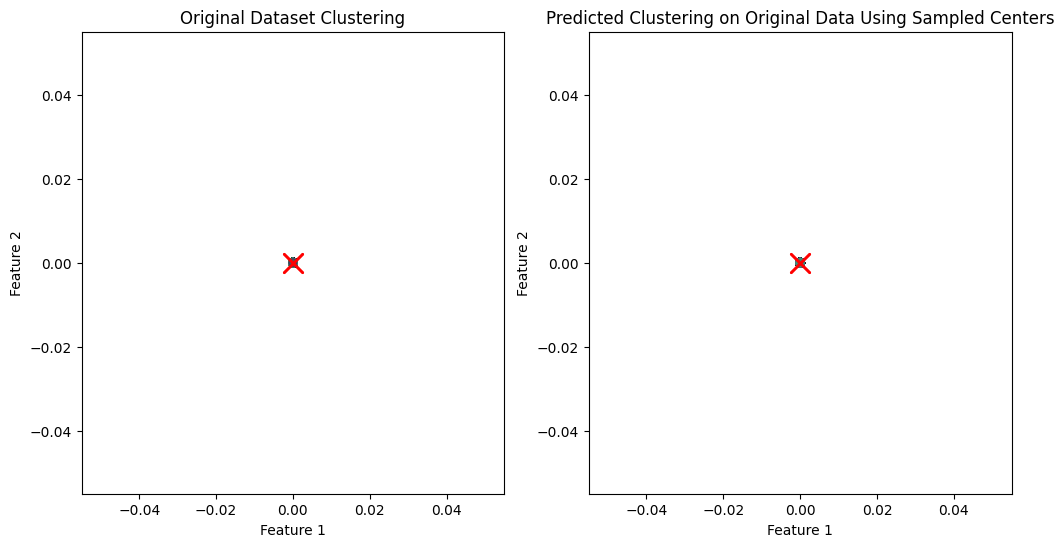

In [8]:
predicted_labels = predict(test_images_vector, centers1)

compare_and_evaluate_clusters(test_images_vector,  labels, centers,centers1, predicted_labels)

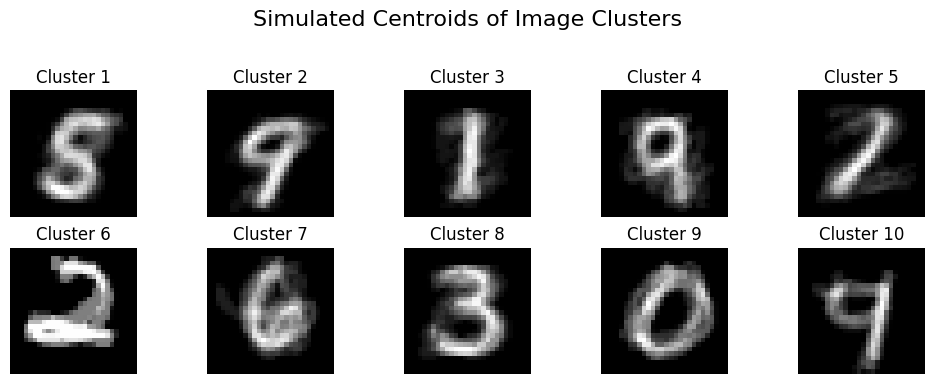

In [9]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(centers1[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


time to cluster entire dataset :  68.77197575569153
time to cluster the sampled dataset :  1.5889198780059814
Rand Index: 0.9631


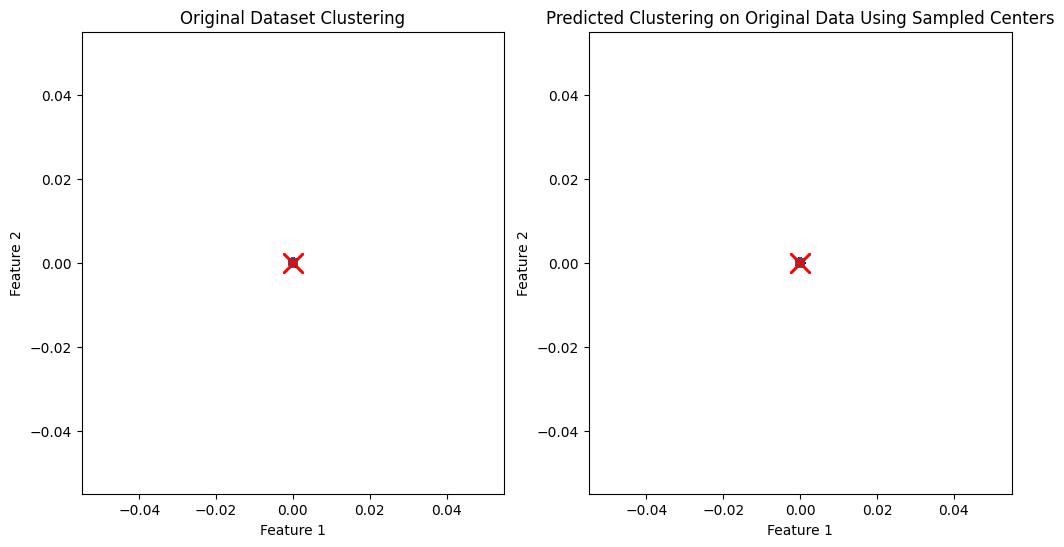

In [10]:
sampled_data = uniform_sample(0.01,train_images_vector)


labels, centers, samay = apply_kmeans_and_time(train_images_vector,10)
labels1, centers1, samay1 = apply_kmeans_and_time(sampled_data,10)

print("time to cluster entire dataset : ",samay)
print("time to cluster the sampled dataset : ",samay1)

predicted_labels = predict(train_images_vector, centers1)


compare_and_evaluate_clusters(train_images_vector,  labels, centers,centers1, predicted_labels)


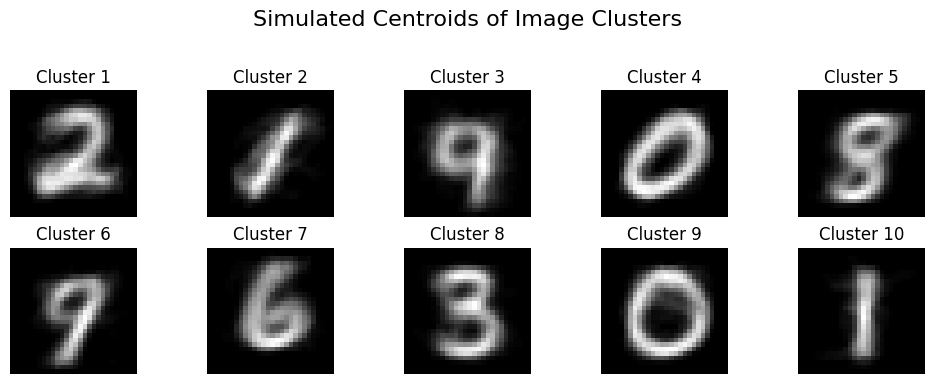

In [11]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(centers1[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [12]:
from keras.datasets import fashion_mnist

import numpy as np

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

test_images_vector = test_images.reshape(test_images.shape[0], -1)
train_images_vector = train_images.reshape(train_images.shape[0], -1)

print(np.shape(test_images_vector))
print(np.shape(train_images_vector))

type(test_images_vector)


(10000, 784)
(60000, 784)


numpy.ndarray

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


time to cluster entire dataset :  63.19976186752319
time to cluster the sampled dataset :  2.115468740463257
Rand Index: 0.9058


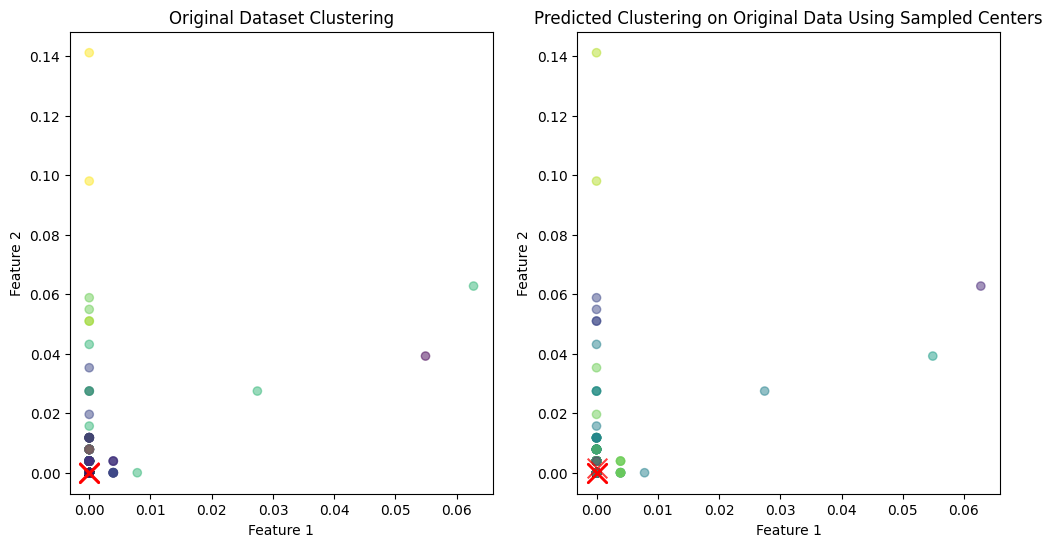

In [13]:
sampled_data = uniform_sample(0.01,train_images_vector)

labels, centers, samay = apply_kmeans_and_time(train_images_vector,10)
labels1, centers1, samay1 = apply_kmeans_and_time(sampled_data,10)

print("time to cluster entire dataset : ",samay)
print("time to cluster the sampled dataset : ",samay1)

predicted_labels = predict(train_images_vector, centers1)

compare_and_evaluate_clusters(train_images_vector,  labels, centers,centers1, predicted_labels)


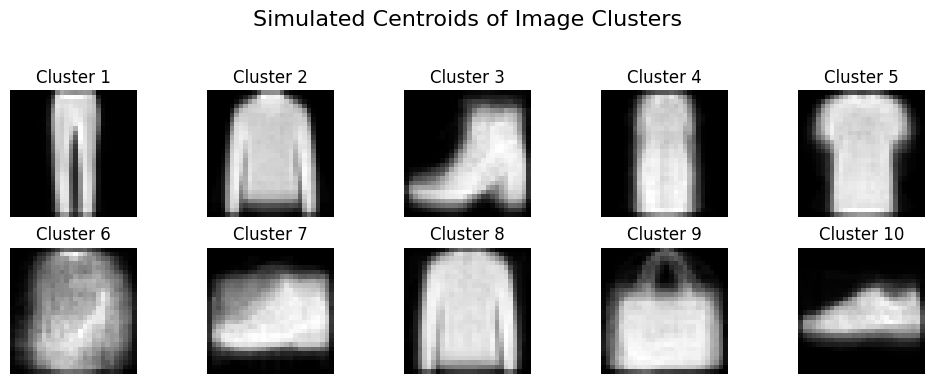

In [14]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(centers1[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


time to cluster entire dataset :  13.581019639968872
time to cluster the sampled dataset :  0.09017252922058105
Rand Index: 0.9250


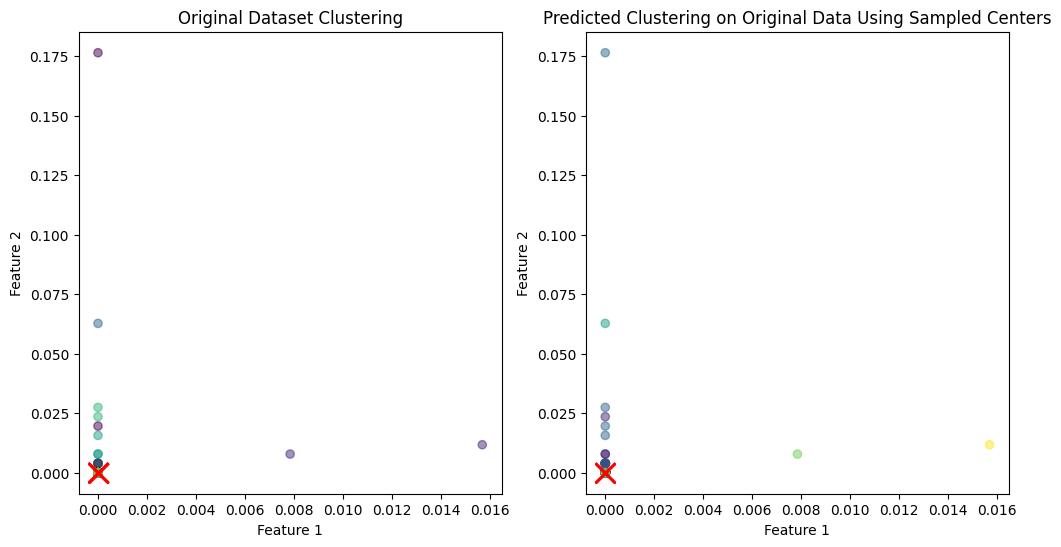

In [15]:
sampled_data = uniform_sample(0.01,test_images_vector)

labels, centers, samay = apply_kmeans_and_time(test_images_vector,10)
labels1, centers1, samay1 = apply_kmeans_and_time(sampled_data,10)

print("time to cluster entire dataset : ",samay)
print("time to cluster the sampled dataset : ",samay1)


predicted_labels = predict(test_images_vector, centers1)

compare_and_evaluate_clusters(test_images_vector,  labels, centers,centers1, predicted_labels)

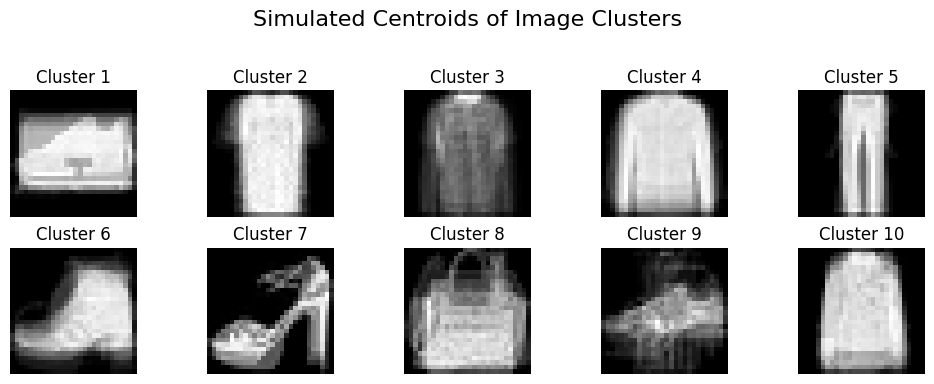

In [16]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(centers1[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

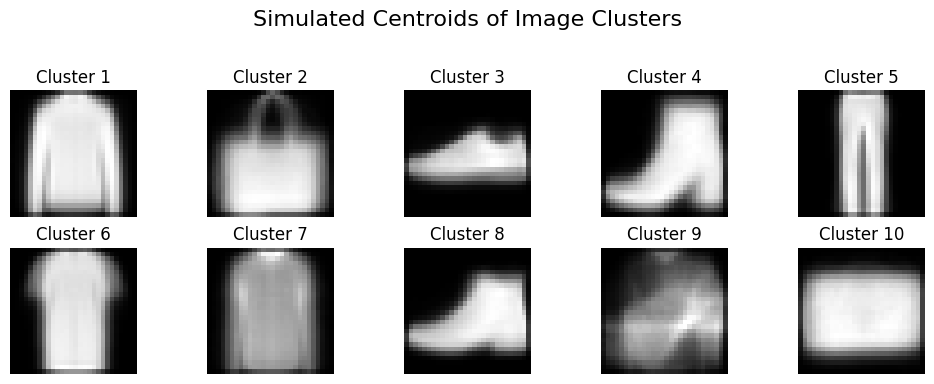

In [17]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Simulated Centroids of Image Clusters', fontsize=16)
for i, ax in enumerate(axs.flat):
    ax.imshow(centers[i].reshape(28,28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Cluster {i+1}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [51]:
traindata = pd.DataFrame(pd.read_csv("/home/manavparmar/Desktop/data science project/data/bio_train.dat", sep="\t", header=None))
traindata = traindata.dropna()
traindata = traindata.drop_duplicates()
print(traindata.shape)
traindata = traindata[:10000]

(145751, 77)


In [52]:
traindata.shape
traindata = np.array(traindata)


In [53]:
def kmeans_cost(data, centers, labels):
    cost = 0.0
    for i in range(len(data)):
        distance = np.linalg.norm(data[i] - centers[labels[i]]) ** 2
        cost += distance
    return cost

print(type(traindata))
traindata = np.array(traindata)
type(traindata)


<class 'numpy.ndarray'>


numpy.ndarray

In [54]:
coreset_size = [500, 1000, 2000, 5000, 7000, 10000]

kmeans = KMeans(n_clusters=50, init='k-means++', random_state=42).fit(traindata)
centers = kmeans.cluster_centers_
cost = kmeans_cost(traindata, centers, kmeans.labels_)
optimal_labels = kmeans.labels_
print(f'Cost of KMeans: {cost}')

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cost of KMeans: 20240766450.872005


In [55]:
results = []

In [56]:
from sklearn.cluster import KMeans

10000
10000


In [57]:
for size in coreset_size:
    avg_cost = 0
    start_time = time.time()
    rand_ind = 0

    for _ in range(5):
        sampled_data = uniform_sample(size/10000, traindata)
        kmeans = KMeans(n_clusters = 50, init = 'k-means++').fit(sampled_data)
        labels = kmeans.predict(traindata)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata, centers, labels)
        rand_ind += rand_score(optimal_labels,labels)

    rand_ind /= 5
    end_time = time.time()
    avg_cost /= 5
    reduction = ((len(traindata) - len(sampled_data)) / len(traindata)) * 100
    error = (abs(avg_cost - cost)/cost) * 100
    results.append({'Sampling Type': 'Uniform Sampling',
                            'Coreset Size': size,
                            'Average Cost': avg_cost,
                            'Reduction in Data Size': reduction,
                            'Error': error,
                            'Avg Rand Index': rand_ind,
                            'Data': 'KDD',
                            'Optimal Cost': cost,
                            'Avg Time': (end_time - start_time)/5
                        })

/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/manavparmar/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will chang

In [65]:
results_df = pd.DataFrame(results)
results_df


,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Uniform Sampling,500,4.542475e+10,95.0,124.422108,0.982942,KDD,2.024077e+10,0.917942
1,Uniform Sampling,1000,4.275983e+10,90.0,111.255987,0.984750,KDD,2.024077e+10,2.190968
2,Uniform Sampling,2000,3.645237e+10,80.0,80.093833,0.985685,KDD,2.024077e+10,1.895225
3,Uniform Sampling,5000,2.582192e+10,50.0,27.573822,0.986264,KDD,2.024077e+10,2.579637
4,Uniform Sampling,7000,2.441829e+10,30.0,20.639164,0.987680,KDD,2.024077e+10,2.642095
5,Uniform Sampling,10000,2.032166e+10,0.0,0.399663,0.985792,KDD,2.024077e+10,3.057903


In [66]:
print("Average error: ", results_df["Error"].mean())
print("Average rand score: ", results_df["Avg Rand Index"].mean())
print("Average cost: ", results_df["Average Cost"].mean())
print("Average time: ", results_df["Avg Time"].mean())

Average error:  60.730762870283606
Average rand score:  0.9855189365603226
Average cost:  32533138327.279003
Average time:  2.2139617919921877


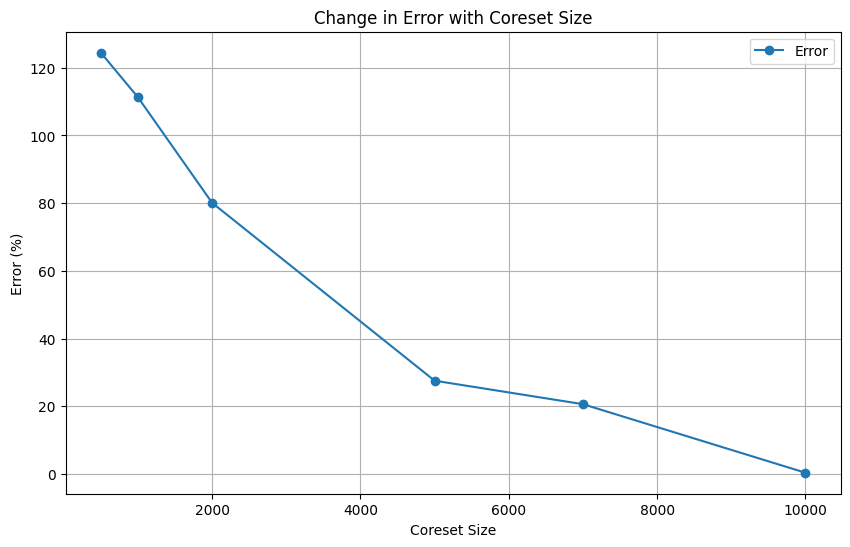

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', label='Error')
plt.legend()
plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error (%)')
plt.grid(True)
plt.show()

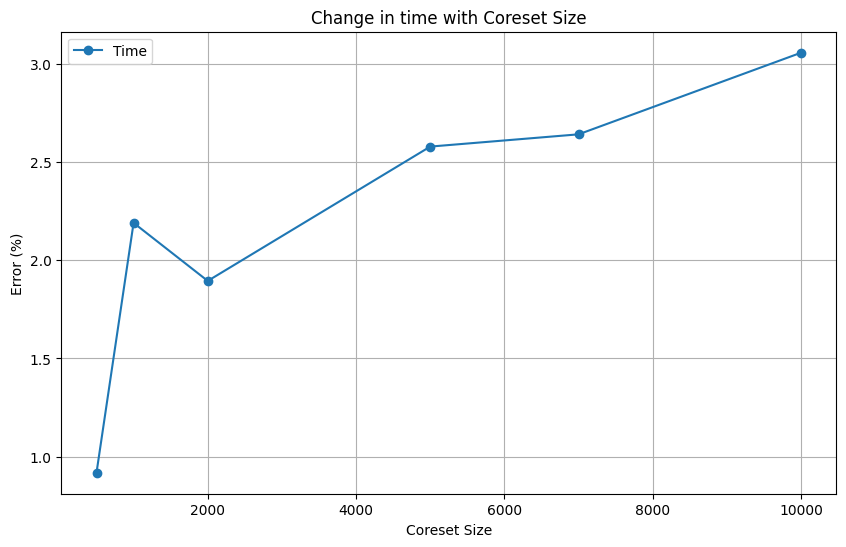

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error (%)')
plt.grid(True)
plt.show()

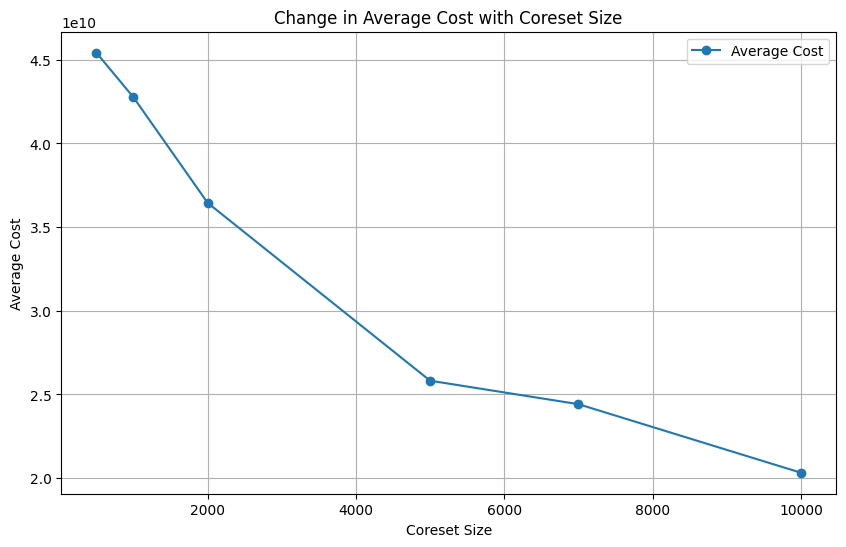

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

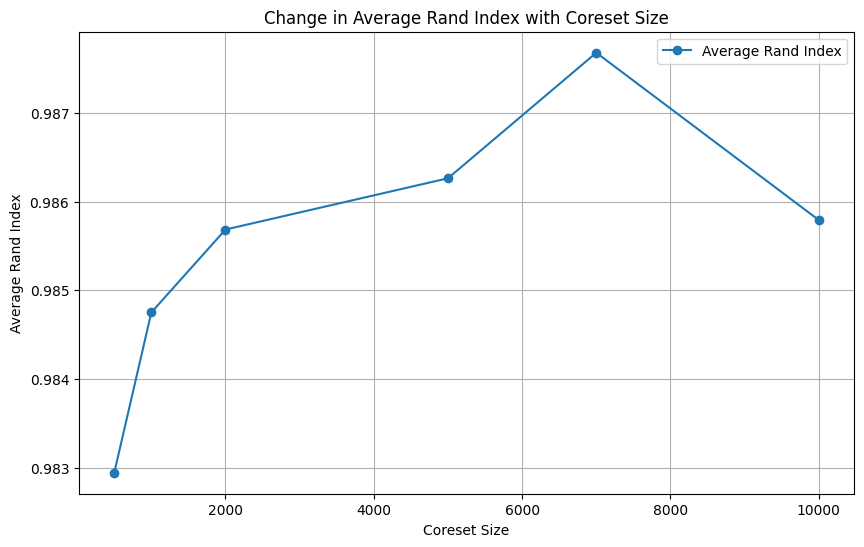

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

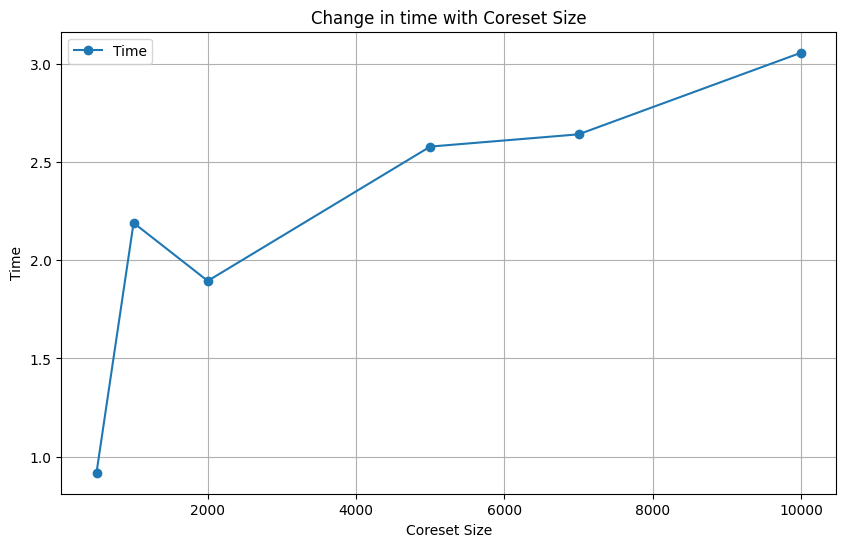

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()